# Required Libraries

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

# Preprocessing: Disruptions

## Preprocessing Disrptions: Load in Data

In [46]:
#Load in dataset services 2019-2022 (0.1s)
dis19 = pd.read_csv("Train Disruptions 2019-2025/disruptions-2019.csv")
dis20 = pd.read_csv("Train Disruptions 2019-2025/disruptions-2020.csv")
dis21 = pd.read_csv("Train Disruptions 2019-2025/disruptions-2021.csv")
dis22 = pd.read_csv("Train Disruptions 2019-2025/disruptions-2022.csv")

In [47]:
#Load in dataset services 2023-2025 (0.0s)
dis23 = pd.read_csv("Train Disruptions 2019-2025/disruptions-2023.csv")
dis24 = pd.read_csv("Train Disruptions 2019-2025/disruptions-2024.csv")
dis25 = pd.read_csv("Train Disruptions 2019-2025/disruptions-2025.csv")

In [48]:
#Concatenate dataset disruption as one (0.1s)

train_disruption = pd.concat([dis19, dis20, dis21, dis22, dis23, dis24, dis25], ignore_index= True)
col_names = train_disruption.columns
print( f" The column names of disruptions are: {col_names}" )

rows, columns = train_disruption.shape
print( f"train_disruption has Rows: {rows}, Columns: {columns}") 

 The column names of disruptions are: Index(['rdt_id', 'ns_lines', 'rdt_lines', 'rdt_lines_id', 'rdt_station_names',
       'rdt_station_codes', 'cause_nl', 'cause_en', 'statistical_cause_nl',
       'statistical_cause_en', 'cause_group', 'start_time', 'end_time',
       'duration_minutes'],
      dtype='str')
train_disruption has Rows: 38571, Columns: 14


In [49]:
cols = ["start_time", "end_time"]
train_disruption[cols] = train_disruption[cols].apply(pd.to_datetime,format="%Y-%m-%d %H:%M:%S",errors="coerce")

## Preprocessing Disrptions: Analyzing the Data

In [6]:
# Check for duplicates 
train_disruption.duplicated().sum()

np.int64(0)

In [7]:
# Display basic information about the DataFrame: 
# number of rows, columns, data types, and non-null counts

train_disruption.info()

<class 'pandas.DataFrame'>
RangeIndex: 38571 entries, 0 to 38570
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   rdt_id                38571 non-null  int64         
 1   ns_lines              38571 non-null  str           
 2   rdt_lines             38559 non-null  str           
 3   rdt_lines_id          38559 non-null  str           
 4   rdt_station_names     38563 non-null  str           
 5   rdt_station_codes     38563 non-null  str           
 6   cause_nl              38571 non-null  str           
 7   cause_en              38571 non-null  str           
 8   statistical_cause_nl  38571 non-null  str           
 9   statistical_cause_en  38571 non-null  str           
 10  cause_group           38569 non-null  str           
 11  start_time            38571 non-null  datetime64[us]
 12  end_time              38461 non-null  datetime64[us]
 13  duration_minutes      38460

In [8]:
# Display summary statistics for numerical columns
train_disruption.describe()

,rdt_id,start_time,end_time,duration_minutes
count,38571.000000,38571,38461,38460.000000
mean,44571.139224,2022-08-23 21:43:15.547380,2022-08-24 23:05:10.075895,162.620281
min,25236.000000,2019-01-01 06:32:16,2019-01-01 06:33:31,0.000000
25%,34878.500000,2020-10-28 15:19:09.500000,2020-10-27 22:14:26,18.000000
50%,44521.000000,2022-09-20 11:18:11,2022-09-22 11:36:57,47.000000
75%,54316.500000,2024-07-04 18:33:56,2024-07-06 01:12:05,131.000000
max,63959.000000,2025-12-31 19:41:03,2025-12-31 21:15:20,45302.000000
std,11193.096194,NaN,NaN,859.044243


In [9]:
# Display summary for categorical columns
train_disruption.describe(include=["object", "string", "category"]) 

,ns_lines,rdt_lines,rdt_lines_id,rdt_station_names,rdt_station_codes,cause_nl,cause_en,statistical_cause_nl,statistical_cause_en,cause_group
count,38571,38559,38559,38563,38563,38571,38571,38571,38571,38569
unique,1517,518,518,1951,1951,95,91,95,91,9
top,Rotterdam-Breda (HSL),Breda - Rotterdam Centraal (HSL),15,"Breda,Rotterdam Centraal","BD, RTD",defecte trein,broken down train,defecte trein,broken down train,rolling stock
freq,1090,1385,1385,1385,1385,13566,13566,13600,13600,16478


In [10]:
# Check if cause_en and statistical_cause_en columns are equal
train_disruption['cause_en'].equals(train_disruption['statistical_cause_en'])

False

In [11]:
# Check for values in 'cause_en' and 'statistical_cause_en' columns that are not the same
train_disruption.loc[train_disruption[['cause_en','statistical_cause_en']].nunique(1)>1]

,rdt_id,ns_lines,rdt_lines,rdt_lines_id,rdt_station_names,rdt_station_codes,cause_nl,cause_en,statistical_cause_nl,statistical_cause_en,cause_group,start_time,end_time,duration_minutes
90,25326,Utrecht-'s-Hertogenbosch,"'s-Hertogenbosch - Utrecht Centraal, Tiel - Ut...","150,151","Houten,Houten Castellum,Utrecht Centraal,Utrec...","HTN, HTNC, UT, UTLN, UTVR",eerdere verstoring,an earlier disruption,gestrande trein,stranded train,rolling stock,2019-01-07 17:57:09,2019-01-07 19:58:12,121.0
102,25338,Nijmegen-Venray,Nijmegen - Venlo,64,"Boxmeer,Cuijk,Mook-Molenhoek,Nijmegen,Nijmegen...","BMR, CK, MMLH, NM, NMH, VLB, VRY",eerdere verstoring,an earlier disruption,defecte trein,broken down train,rolling stock,2019-01-08 08:54:11,2019-01-08 12:51:10,237.0
121,25357,Amsterdam-Schiphol-Rotterdam (HSL),"Amsterdam Centraal - Schiphol Airport, Rotterd...","24,32","Amsterdam Centraal,Amsterdam Lelylaan,Amsterda...","ASD, ASDL, ASS, RTD, SHL",eerdere verstoring,an earlier disruption,verstoring elders,disruption elsewhere,logistical,2019-01-08 18:56:19,2019-01-09 02:11:02,435.0
284,25520,Nijmegen-Roermond,Nijmegen - Venlo,64,"Boxmeer,Cuijk,Mook-Molenhoek,Nijmegen,Nijmegen...","BMR, CK, MMLH, NM, NMH, VLB, VRY",eerdere verstoring,an earlier disruption,defecte trein,broken down train,rolling stock,2019-01-18 12:15:03,2019-01-18 15:02:05,167.0
468,25704,Schiphol Airport,"Amersfoort - Schiphol Airport, Amsterdam Centr...","22,24,32,137,144,148,165",Schiphol Airport,SHL,eerdere verstoring,an earlier disruption,inzet van de brandweer,deployment of the fire department,external,2019-01-25 18:06:18,2019-01-25 19:32:17,86.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37607,62996,Heerlen - Maastricht,Heerlen - Maastricht,76,"Heerlen,Heerlen Woonboulevard,Klimmen-Ransdaal...","HRL, HRLW, KMR, MES, MT, SGL, SOG, VDL, VK, MTN",eerdere verstoring,an earlier disruption,problemen met de personeelsinzet,staffing problems,staff,2025-11-07 09:30:53,2025-11-07 11:44:18,133.0
37655,63044,Amsterdam Centraal,"Alkmaar - Amsterdam Centraal, Amersfoort - Ams...","32,112,135,136,141,145,161,164","Amsterdam Centraal,Twello,Kontich","ASD, TWL, FKI",eerdere verstoring,an earlier disruption,persoon op het spoor,person on the railway track,external,2025-11-10 18:48:49,2025-11-10 20:31:23,103.0
37977,63366,Groningen - Bad Nieuweschans; Groningen - Veendam,"Groningen - Bad Nieuweschans, Groningen - Leer...","154,155,156","Groningen Europapark,Groningen,Hoogezand-Sappe...","GERP, GN, HGZ, KW, MTH, ZB",eerdere verstoring,an earlier disruption,defecte trein,broken down train,rolling stock,2025-11-25 12:22:06,2025-11-25 15:25:07,183.0
38507,63896,Amsterdam Centraal,"Alkmaar - Amsterdam Centraal, Amersfoort - Ams...","32,112,135,136,141,145,161,164","Amsterdam Centraal,Twello,Kontich","ASD, TWL, FKI",eerdere verstoring,an earlier disruption,persoon op het spoor,person on the railway track,external,2025-12-27 21:49:29,2025-12-27 22:36:17,47.0


In [50]:
# Remove the following columns
train_disruption = train_disruption.drop(['cause_nl', 'cause_en', 'statistical_cause_nl'], axis=1)

In [13]:
#Check if drop columns was successful 
train_disruption.columns.values

<StringArray>
[              'rdt_id',             'ns_lines',            'rdt_lines',
         'rdt_lines_id',    'rdt_station_names',    'rdt_station_codes',
 'statistical_cause_en',          'cause_group',           'start_time',
             'end_time',     'duration_minutes']
Length: 11, dtype: str

## Preprocessing Disrptions: Dealing with Missing Values

In [14]:
# Check for missing values in each column and calculate the percentage of missing values
total = train_disruption.isnull().sum().sort_values(ascending=False)
percent = (train_disruption.isnull().sum()/train_disruption.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data

,Total,Percent
duration_minutes,111,0.002878
end_time,110,0.002852
rdt_lines,12,0.000311
rdt_lines_id,12,0.000311
rdt_station_names,8,0.000207
rdt_station_codes,8,0.000207
cause_group,2,0.000052
ns_lines,0,0.000000
rdt_id,0,0.000000
statistical_cause_en,0,0.000000


In [15]:
# Display rows with missing values
null_data = train_disruption[train_disruption.isnull().any(axis=1)]
null_data

,rdt_id,ns_lines,rdt_lines,rdt_lines_id,rdt_station_names,rdt_station_codes,statistical_cause_en,cause_group,start_time,end_time,duration_minutes
629,25865,Amsterdam-Brussel-Paris (HSL),NaN,NaN,NaN,NaN,disruption elsewhere,logistical,2019-02-03 22:06:26,2019-02-03 22:08:03,2.0
681,25917,Alkmaar-Hoorn,NaN,NaN,Hoorn,HN,broken down train,rolling stock,2019-02-06 16:41:05,2019-02-06 16:50:47,10.0
3080,28316,Hoofddorp-Schiphol-Almere Oostvaarders,NaN,NaN,Hoofddorp,HFD,broken down train,rolling stock,2019-07-04 19:58:18,2019-07-04 19:59:03,1.0
4072,29308,Zwolle-Groningen,Groningen - Zwolle,146,"Assen,Beilen,Hoogeveen,Meppel,Zwolle","ASN, BL, HGV, MP, ZL",broken down train,rolling stock,2019-09-04 20:24:37,NaT,NaN
4479,29715,Amsterdam-Köln-Frankfurt,Arnhem Centraal - Utrecht Centraal,133,"Arnhem Centraal,Bunnik,Driebergen-Zeist,Ede-Wa...","AH, BNK, DB, ED, KLP, MRN, OTB, UT, WF, UTVR",person hit by a train,accidents,2019-10-02 07:13:40,NaT,NaN
...,...,...,...,...,...,...,...,...,...,...,...
30742,56131,Amersfoort - Zwolle,Amersfoort - Zwolle,48,"Amersfoort Centraal,Amersfoort Schothorst,Amer...","AMF, AMFS, AVAT, EML, HD, HDE, NKK, NS, PT, WZ...",police action,external,2024-10-24 21:21:23,NaT,NaN
31443,56832,Amsterdam - Gouda,"Amsterdam Centraal - Utrecht Centraal, Amsterd...","136,141","Abcoude,Amsterdam Amstel,Amsterdam Bijlmer Are...","AC, ASA, ASB, ASD, ASDM, ASHD, BKL, DVD",deployment of security staff,NaN,2024-12-01 19:34:39,2024-12-01 20:09:45,35.0
34490,59879,Deventer - Enschede; Zwolle - Enschede,Almelo - Hengelo,89,"Almelo,Almelo de Riet,Borne,Hengelo","AML, AMRI, BN, HGL",signal failure,infrastructure,2025-05-15 09:54:45,NaT,NaN
34824,60213,'s-Hertogenbosch - Tilburg,'s-Hertogenbosch - Tilburg,69,"'s-Hertogenbosch,Tilburg","HT, TB",collision,accidents,2025-06-04 19:14:28,NaT,NaN


In [51]:
# Make a list of numerical and categorical columns
num_cols = train_disruption.select_dtypes(include=np.number).columns  # rdt_id and duration_minutes
cat_cols = train_disruption.select_dtypes(exclude=np.number).columns

# Drop whole row if start_time or end_time is missing
# and duration_minutes is also missing, or if duration_minutes is missing
drop_rows = (
    ((train_disruption["start_time"].isna() | train_disruption["end_time"].isna())
    & train_disruption["duration_minutes"].isna())
    | train_disruption["duration_minutes"].isna()
)
train_disruption = train_disruption.loc[~drop_rows].copy()

# Fill specific categorical columns with 'Unknown'
cols_to_fill = ["rdt_lines", "rdt_lines_id", "rdt_station_names", "rdt_station_codes", "cause_group"]

for col in cols_to_fill:
    train_disruption[col] = train_disruption[col].fillna("Unknown")

## Preprocessing Disrptions: Dealing with outliers (duration_minutes)

### Preprocessing Disrptions: General Univariate Analysis for duration_minutes

duration_minutes
0–15 min       8573
16–30 min      5908
31–60 min      7214
61–120 min     6336
120+ min      10429
Name: count, dtype: int64

duration_minutes
0–15 min       8573
16–30 min      5908
31–60 min      7214
61–120 min     6336
120+ min      10429
Name: count, dtype: int64

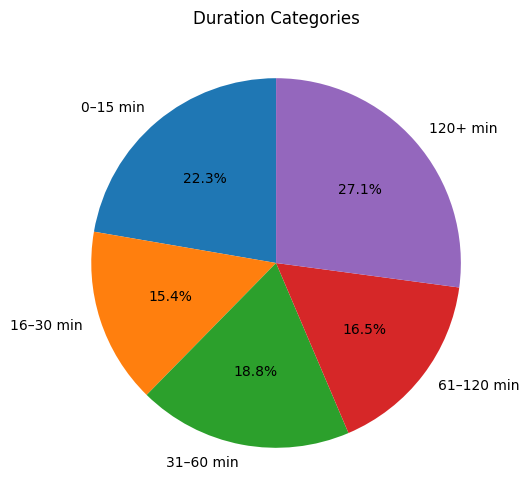

duration_minutes
0–15 min       8573
16–30 min      5908
31–60 min      7214
61–120 min     6336
120+ min      10429
Name: count, dtype: int64

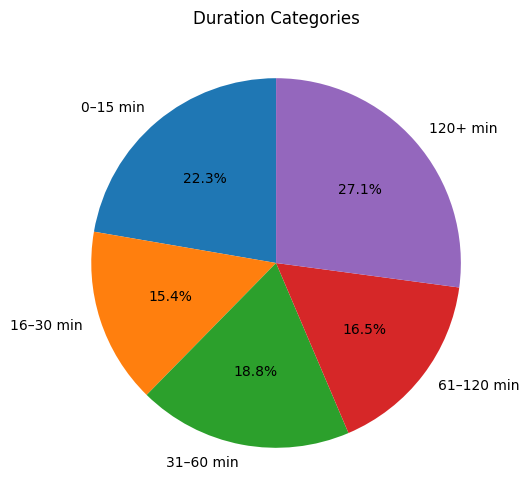

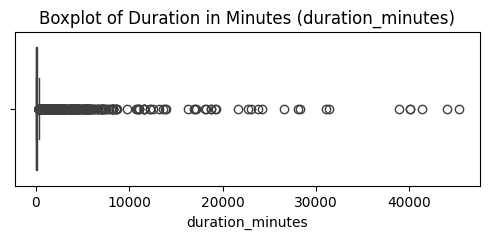

In [17]:
# General Univariate analysis for duration_minutes
duration = train_disruption["duration_minutes"].dropna()

# Categorize duration into groups
bins = [0, 15, 30, 60, 120, np.inf]
labels = ["0–15 min", "16–30 min", "31–60 min", "61–120 min", "120+ min"]

duration_bins = pd.cut(
    train_disruption["duration_minutes"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Counts per category
duration_counts = duration_bins.value_counts().sort_index()
display(duration_counts)

# Pie chart: Check the distribution of duration_minutes
plt.figure(figsize=(6, 6))
plt.pie(duration_counts, labels=duration_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Duration Categories")
plt.show()

# Boxplot: Check the distribution of duration_minutes
plt.figure(figsize=(6, 2))
sns.boxplot(x=train_disruption['duration_minutes'])
plt.title("Boxplot of Duration in Minutes (duration_minutes)")
plt.show()

In [18]:
# Summary statistics
display(train_disruption['duration_minutes'].describe())

count    38460.000000
mean       162.620281
std        859.044243
min          0.000000
25%         18.000000
50%         47.000000
75%        131.000000
max      45302.000000
Name: duration_minutes, dtype: float64

In [52]:
# Identify outliers in duration_minutes using the Interquartile Range (IQR) method
# https://www.geeksforgeeks.org/pandas/handling-outliers-with-pandas/ 

Q1 = train_disruption['duration_minutes'].quantile(0.25) #18 minutes
Q3 = train_disruption['duration_minutes'].quantile(0.75) #131 minutes
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove legacy category column from previous runs (if present)
train_disruption = train_disruption.drop(columns=["duration_category"], errors="ignore")

outliers = train_disruption[(train_disruption['duration_minutes'] < lower_bound) | (train_disruption['duration_minutes'] > upper_bound)]
display(outliers)

# 38571 rows, 11 columns, and 3427 rows of outliers in duration_minutes column. 8.88% of the data are outliers.
# 1 day = 1440 minutes

,rdt_id,ns_lines,rdt_lines,rdt_lines_id,rdt_station_names,rdt_station_codes,statistical_cause_en,cause_group,start_time,end_time,duration_minutes
35,25271,Zwolle-Groningen,Groningen - Zwolle,146,"Hoogeveen,Meppel","HGV, MP",broken down train,rolling stock,2019-01-04 04:56:09,2019-01-05 22:47:07,2511.0
69,25305,Hengelo-Bielefeld,"Berlin Ostbahnhof - Hengelo, Bielefeld Hbf - H...","91,124,174","Bad Bentheim,Hengelo,Hengelo Oost,Oldenzaal","BH, HGL, HGLO, ODZ",problems with the rolling stock,rolling stock,2019-01-06 08:25:05,2019-01-06 21:49:09,804.0
89,25325,Hoofddorp-Schiphol-Hilversum,"Amersfoort - Schiphol Airport, Leiden Centraal...","22,137,144,148","Amsterdam Zuid,Hoofddorp,Schiphol Airport","ASDZ, HFD, SHL",points failure,infrastructure,2019-01-07 14:20:47,2019-01-07 20:59:41,399.0
97,25333,Alkmaar-Den Helder; Alkmaar-Hoorn,"Alkmaar - Den Helder, Alkmaar - Hoorn","162,163","Alkmaar,Alkmaar Noord,Heerhugowaard","AMR, AMRN, HWD",person hit by a train,accidents,2019-01-07 23:49:33,2019-01-08 07:18:42,449.0
110,25346,Rotterdam-Breda (HSL),Breda - Rotterdam Centraal (HSL),15,"Breda,Rotterdam Centraal","BD, RTD",points failure,infrastructure,2019-01-08 15:08:31,2019-01-08 20:27:42,319.0
...,...,...,...,...,...,...,...,...,...,...,...
38524,63913,Amsterdam - Utrecht; Amsterdam - Gouda,"Amsterdam Centraal - Utrecht Centraal, Amsterd...","136,141","Amsterdam Amstel,Amsterdam Bijlmer ArenA,Amste...","ASA, ASB, ASD, ASDM, DVD",damaged overhead wires,infrastructure,2025-12-29 14:08:11,2025-12-30 00:34:19,626.0
38531,63920,Amersfoort - Barneveld,Amersfoort - Ede-Wageningen,47,"Amersfoort Centraal,Barneveld Centrum,Barnevel...","AMF, BNC, BNN, HVL, BNZ",problems with the rolling stock,rolling stock,2025-12-30 04:25:09,2025-12-30 20:45:56,981.0
38533,63922,Heerlen - Aachen Hbf,Aachen Hbf - Heerlen,130,"Aachen Hbf,Eygelshoven Markt,Heerlen,Herzogenr...","AHBF, EGHM, HRL, HZ, LG, AW",overhead wires covered with frost,weather,2025-12-30 07:22:49,2025-12-30 13:01:22,339.0
38550,63939,Maastricht - Heerlen - Aachen,"Aachen Hbf - Heerlen, Heerlen - Maastricht","76,130","Aachen Hbf,Eygelshoven Markt,Heerlen,Heerlen W...","AHBF, EGHM, HRL, HRLW, HZ, KMR, LG, MES, MT, S...",ice formation on the overhead wires,weather,2025-12-31 03:39:10,2025-12-31 08:56:59,318.0


In [20]:
outliers.sort_values(by='duration_minutes', ascending=False).head(10)

,rdt_id,ns_lines,rdt_lines,rdt_lines_id,rdt_station_names,rdt_station_codes,statistical_cause_en,cause_group,start_time,end_time,duration_minutes
18389,43625,Roermond-Sittard,Roermond - Sittard,73,"Echt,Roermond,Susteren,Sittard","EC, RM, SRN, STD",damaged railway bridge,accidents,2022-07-16 05:29:58,2022-08-16 16:31:29,45302.0
15286,40522,Hengelo-Bielefeld,"Berlin Ostbahnhof - Hengelo, Bielefeld Hbf - H...","91,124,174","Bad Bentheim,Hengelo,Hengelo Oost,Oldenzaal","BH, HGL, HGLO, ODZ",problems with the rolling stock,rolling stock,2022-01-03 09:07:30,2022-02-02 22:43:56,44016.0
21762,46998,Leeuwarden-Stavoren,Leeuwarden - Stavoren,104,"Hindeloopen,IJlst,Koudum-Molkwerum,Sneek,Stavo...","HNP, IJT, KMW, SK, STV, WK",repair works,engineering work,2023-03-13 16:04:47,2023-04-11 10:04:04,41339.0
21272,46508,Leeuwarden,"Groningen - Leeuwarden, Harlingen Haven - Leeu...","102,103,104,160",Leeuwarden,LW,strike of Arriva staff,staff,2023-02-08 04:48:23,2023-03-08 01:07:41,40099.0
21273,46509,Groningen,"Delfzijl - Groningen, Groningen - Bad Nieuwesc...","102,146,154,155,156,157,158",Groningen,GN,strike of Arriva staff,staff,2023-02-08 04:48:27,2023-03-08 01:07:28,40099.0
21276,46512,Groningen-Leeuwarden,Groningen - Leeuwarden,102,"Buitenpost,Grijpskerk,Groningen,Hurdegaryp,Lee...","BP, GK, GN, HDG, LW, LWC, ZH, DWE, FWD",strike of Arriva staff,staff,2023-02-08 07:29:20,2023-03-07 07:22:52,38874.0
33843,59232,Maastricht - Liège / Luik,"Liège-Guillemins - Maastricht, Maastricht - Ma...","75,121","Bressoux,Eijsden,Visé,Liège-Guillemins,Maastri...","BRESSX, EDN, FVS, LUIK, MT, MTR",staff strikes abroad,staff,2025-04-08 05:18:14,2025-04-29 23:49:11,31351.0
31471,56860,Heerlen - Maastricht,Heerlen - Maastricht,76,"Heerlen,Heerlen Woonboulevard,Klimmen-Ransdaal...","HRL, HRLW, KMR, MES, MT, SGL, SOG, VDL, VK, MTN",problems with the rolling stock,rolling stock,2024-12-03 10:15:01,2024-12-25 00:15:23,31080.0
31832,57221,Maastricht - Heerlen - Aachen,Heerlen - Maastricht,76,"Heerlen,Heerlen Woonboulevard,Klimmen-Ransdaal...","HRL, HRLW, KMR, MES, MT, SGL, SOG, VDL, VK, MTN",problems with the rolling stock,rolling stock,2024-12-27 07:45:33,2025-01-16 00:02:17,28337.0
15199,40435,Amsterdam-Rotterdam-Brussel (HSL),"Amsterdam Centraal - Schiphol Airport, Brussel...","24,32,123,167","Amsterdam Centraal,Amsterdam Lelylaan,Amsterda...","ASD, ASDL, ASS, ATW, BRUSC, BRUSN, BRUSZ, MECH...",large crowds,external,2021-12-28 10:33:56,2022-01-16 21:59:29,28046.0


In [21]:
train_disruption[['statistical_cause_en']].value_counts()

statistical_cause_en        
broken down train               13569
collision                        3064
signal failure                   2579
stranded train                   2288
points failure                   2058
                                ...  
emergency repairs                   2
fire in a train                     1
the construction of a tunnel        1
pilgrimage                          1
snow                                1
Name: count, Length: 91, dtype: int64

In [22]:
# Top 15 causes in outliers
outliers_top15 = outliers["statistical_cause_en"].value_counts().head(15)

# Count those same causes in full dataset (train_disruption)
train_disruption_for_outlier_top15 = (
    train_disruption["statistical_cause_en"]
    .value_counts()
    .reindex(outliers_top15.index, fill_value=0)
)

# Percentage of outliers relative to full dataset for the same cause
outlier_percentage = (
    outliers_top15.div(train_disruption_for_outlier_top15.replace(0, np.nan)) * 100
).round(2)

# Show side by side
pd.DataFrame({
    "outliers_top15": outliers_top15,
    "cause_total": train_disruption_for_outlier_top15,
    "percentage": outlier_percentage
})

,outliers_top15,cause_total,percentage
statistical_cause_en,,,
staffing problems,399,570,70.00
problems with the rolling stock,364,568,64.08
damaged overhead wires,297,839,35.40
signal failure,277,2579,10.74
defective railway track,201,597,33.67
logistical limitations,194,451,43.02
points failure,187,2058,9.09
repair works,182,741,24.56
strike,112,133,84.21


### Preprocessing Disrptions: Outlier Univariate Analysis for duration_minutes

duration_minutes
241–480 min     1338
481–720 min      774
721–1440 min     936
1440+ min        379
Name: count, dtype: int64

duration_minutes
241–480 min     1338
481–720 min      774
721–1440 min     936
1440+ min        379
Name: count, dtype: int64

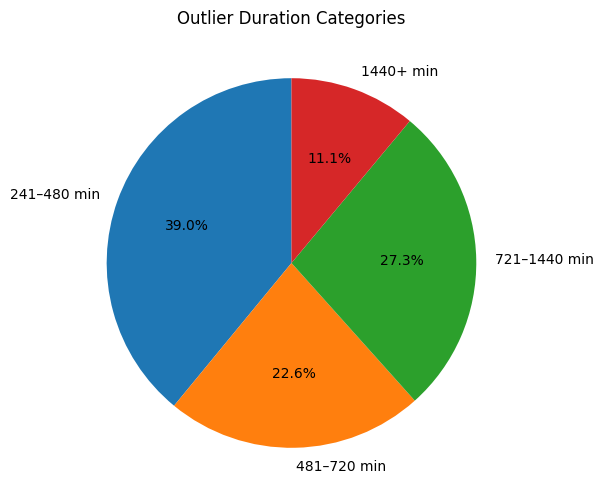

In [23]:
# Univariate analysis for outliers duration_minutes
duration = outliers["duration_minutes"].dropna()

# Categorize outliers into groups (all outliers are above upper_bound ~264 min)
bins = [240, 480, 720, 1440, np.inf] #bins 0-240 was removed because all outliers are above 240 minutes
labels = ["241–480 min", "481–720 min", "721–1440 min", "1440+ min"]

outlier_duration_bins = pd.cut(
    outliers["duration_minutes"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Counts per category
duration_counts = outlier_duration_bins.value_counts().sort_index()
display(duration_counts)

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(duration_counts, labels=duration_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Outlier Duration Categories")
plt.show()

In [53]:
outliers_720 = train_disruption["duration_minutes"] > 720
count_over_720 = outliers_720.sum()
total_rows = len(train_disruption)
pct_over_720 = (count_over_720 / total_rows) * 100 if total_rows else 0

print(f"Rows with duration_minutes that are more than 720 min: {count_over_720}, which is {pct_over_720:.2f}% of the dataset ({total_rows} rows)")

Rows with duration_minutes that are more than 720 min: 1315, which is 3.42% of the dataset (38460 rows)


In [54]:
drop_rows = train_disruption["duration_minutes"] > 720
train_disruption = train_disruption.loc[~drop_rows].copy()

In [26]:
train_disruption["duration_minutes"].describe()

count    37145.000000
mean        89.007538
std        114.128517
min          0.000000
25%         17.000000
50%         44.000000
75%        118.000000
max        720.000000
Name: duration_minutes, dtype: float64

## Preprocessing Disrptions: Analysis different years

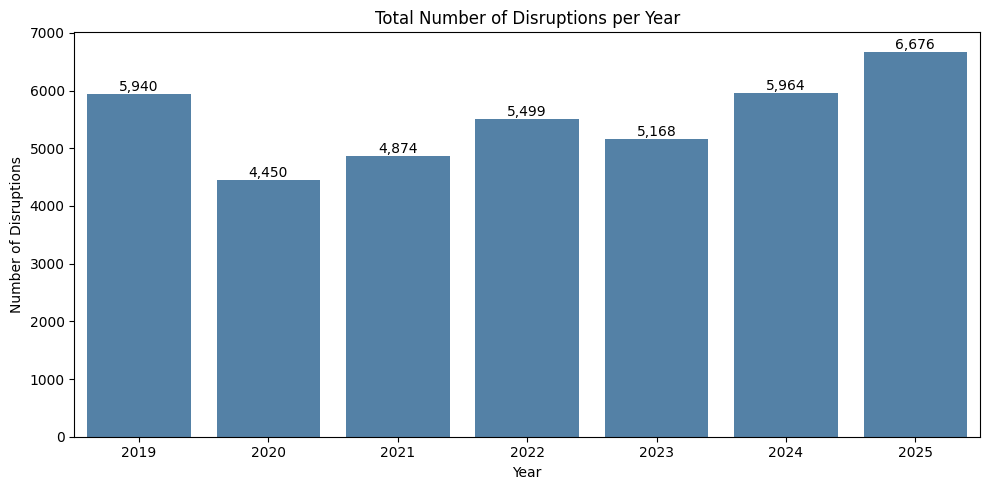

In [27]:
# Histogram of total disruptions per year (2019-2025)
yearly_disruptions = pd.Series({
    "2019": len(dis19),
    "2020": len(dis20),
    "2021": len(dis21),
    "2022": len(dis22),
    "2023": len(dis23),
    "2024": len(dis24),
    "2025": len(dis25),
})

plt.figure(figsize=(10, 5))
sns.barplot(x=yearly_disruptions.index, y=yearly_disruptions.values, color="steelblue")
plt.title("Total Number of Disruptions per Year")
plt.xlabel("Year")
plt.ylabel("Number of Disruptions")

# Show exact counts on top of bars
for i, v in enumerate(yearly_disruptions.values):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [28]:
# Top 10 disruption causes for each year (2019-2025)
yearly_data = {
    "2019": dis19,
    "2020": dis20,
    "2021": dis21,
    "2022": dis22,
    "2023": dis23,
    "2024": dis24,
    "2025": dis25,
}

def cause_group_yearly(df):
    for col in ["cause_group"]:
        if col in df.columns:
            return col

top10_cause_yearly = {}

for year, df in yearly_data.items():
    cause_col = cause_group_yearly(df)
    top10_cause_yearly[year] = (
        df[cause_col]
        .fillna("Unknown")
        .value_counts()
        .head(10)
    )

top10_causes_table = pd.concat(top10_cause_yearly, axis=1).fillna(0).astype(int)
top10_causes_table

,2019,2020,2021,2022,2023,2024,2025
cause_group,,,,,,,
rolling stock,2967,2044,2176,2108,1923,2309,2951
infrastructure,1383,979,1090,1176,1177,1394,1576
accidents,588,529,515,632,539,580,443
external,506,445,567,781,631,804,866
logistical,218,232,255,245,232,187,135
engineering work,175,155,176,228,202,142,149
weather,61,45,66,45,58,26,51
unknown,25,21,16,38,77,252,304
staff,17,0,13,246,329,268,201


In [29]:
# Top 10 statistical causes for each year (2019-2025)
def statistical_cause_yearly(df):
    for col in ["statistical_cause_en"]:
        if col in df.columns:
            return col

top10_statistical_cause = {}

for year, df in yearly_data.items():
    cause_col = statistical_cause_yearly(df)
    top10_statistical_cause[year] = (
        df[cause_col]
        .fillna("Unknown")
        .value_counts()
        .head(10)
    )

top10_statistical_causes_table = pd.concat(top10_statistical_cause, axis=1).fillna(0).astype(int)
top10_statistical_causes_table

,2019,2020,2021,2022,2023,2024,2025
statistical_cause_en,,,,,,,
broken down train,2326,1618,1758,1707,1705,2062,2424
stranded train,535,381,367,295,134,180,399
signal failure,435,354,316,358,163,452,511
points failure,343,231,333,265,231,286,379
person hit by a train,320,0,0,0,0,0,0
an emergency call,181,134,223,358,152,208,180
disruption elsewhere,141,0,0,0,0,0,0
collision,138,488,472,565,495,515,404
damaged overhead wires,136,120,0,156,0,129,0


# Preprocessing: Weather 

## Preprocessing Weather: Load in Data

In [55]:
# Read KNMI weather file (.txt can still be comma-delimited and read with read_csv)
weather = pd.read_csv(
    "Weather 2019-2025/homogenoues weather data.txt",
    sep=",",
    skiprows=51,
    header=0,
    low_memory=False
 )

# Parse date column once so later filtering works reliably
weather["YYYYMMDD"] = pd.to_datetime(weather["YYYYMMDD"], format="%Y%m%d", errors="coerce")

# Keep only rows from 2019-01-01 through 2025-12-31 (inclusive)
start_date = pd.Timestamp("2019-01-01")
end_date = pd.Timestamp("2025-12-31")
weather = weather[(weather["YYYYMMDD"] >= start_date) & (weather["YYYYMMDD"] <= end_date)].copy()

In [56]:
# Normalize KNMI headers, so that mapping keys match
weather.columns = weather.columns.str.strip().str.lstrip("#").str.strip()

# Map original column names to more descriptive labels
column_map = {
    'STN': 'Station',
    'YYYYMMDD': 'Date',
    'DDVEC': 'Wind direction vector mean',  # degrees: 0=N, 90=E, 180=S, 270=W
    'FHVEC': 'Windspeed vector mean',
    'FG': 'Daily mean windspeed',
    'FHX': 'Max hourly mean windspeed',
    'FHXH': 'Hour of max hourly mean windspeed',
    'FHN': 'Min hourly mean windspeed',
    'FHNH': 'Hour of min hourly mean windspeed',
    'FXX': 'Max wind gust',
    'FXXH': 'Hour of max wind gust',
    'TG': 'Daily mean temperature',  # 0.1 degrees Celsius
    'TN': 'Min temperature',  # 0.1 degrees Celsius
    'TNH': 'Hour TN measured',
    'TX': 'Max temperature',  # 0.1 degrees Celsius
    'TXH': 'Hour TX measured',
    'T10N': 'Min temperature 10cm above surface',  # 0.1 degrees Celsius
    'T10NH': '6-hour period T10N measured',
    'SQ': 'Sunshine duration',  # 0.1 hour
    'SP': 'Percent max potential sunshine duration',
    'Q': 'Global radiation',  # J/cm2
    'DR': 'Precipitation duration',  # 0.1 hour
    'RH': 'Daily precipitation amount',  # 0.1 mm
    'RHX': 'Max hourly precipitation amount',  # 0.1 mm
    'RHXH': 'Hour RHX measured',
    'PG': 'Daily mean sea level pressure',  # 0.1 hPa
    'PX': 'Max hourly sea level pressure',  # 0.1 hPa
    'PXH': 'Hour PX measured',
    'PN': 'Min hourly sea level pressure',  # 0.1 hPa
    'PNH': 'Hour PN measured',
    'VVN': 'Min visibility',  # 0.1 km
    'VVNH': 'Hour VVN measured',
    'VVX': 'Max visibility',  # 0.1 km
    'VVXH': 'Hour VVX measured',
    'NG': 'Mean daily cloud cover',  # octas
    'UG': 'Daily mean relative humidity',  # percent
    'UX': 'Max relative humidity',  # percent
    'UXH': 'Hour UX measured',
    'UN': 'Min relative humidity',  # percent
    'UNH': 'Hour UN measured',
    'EV24': 'Potential evapotranspiration (Makkink)'  # 0.1 mm
}

weather = weather.rename(columns=column_map)

# Convert all columns except Date to numeric (spaces become NaN)
num_cols = [c for c in weather.columns if c != 'Date']
weather[num_cols] = weather[num_cols].apply(pd.to_numeric, errors='coerce')

# Resolve cloud-cover column name robustly
if 'Mean daily cloud cover' in weather.columns:
    cloud_col = 'Mean daily cloud cover'
elif 'NG' in weather.columns:
    cloud_col = 'NG'
else:
    candidates = [c for c in weather.columns if 'cloud' in c.lower()]
    cloud_col = candidates[0] if candidates else None

## Preprocessing Weather: Analyzing the Data

In [32]:
# Display basic information about the DataFrame: 
# number of rows, columns, data types, and non-null counts

weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 2557 entries, 43099 to 45655
Data columns (total 41 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Station                                  2557 non-null   int64         
 1   Date                                     2557 non-null   datetime64[us]
 2   Wind direction vector mean               2557 non-null   int64         
 3   Windspeed vector mean                    2557 non-null   int64         
 4   Daily mean windspeed                     2557 non-null   int64         
 5   Max hourly mean windspeed                2557 non-null   int64         
 6   Hour of max hourly mean windspeed        2557 non-null   int64         
 7   Min hourly mean windspeed                2557 non-null   int64         
 8   Hour of min hourly mean windspeed        2557 non-null   int64         
 9   Max wind gust                            2557 n

In [33]:
weather.describe()

,Station,Date,Wind direction vector mean,Windspeed vector mean,Daily mean windspeed,Max hourly mean windspeed,Hour of max hourly mean windspeed,Min hourly mean windspeed,Hour of min hourly mean windspeed,Max wind gust,...,Hour VVN measured,Max visibility,Hour VVX measured,Mean daily cloud cover,Daily mean relative humidity,Max relative humidity,Hour UX measured,Min relative humidity,Hour UN measured,Potential evapotranspiration (Makkink)
count,2557.0,2557,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,...,2557.000000,2557.000000,2557.000000,2554.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000
mean,260.0,2022-07-02 00:00:00,190.808369,29.271412,33.369183,51.286664,10.910442,16.104810,8.427063,102.655456,...,9.897927,78.020727,12.098944,6.060689,79.021118,94.676965,9.556903,61.203363,13.448573,17.732499
min,260.0,2019-01-01 00:00:00,1.000000,0.000000,7.000000,20.000000,1.000000,0.000000,1.000000,30.000000,...,1.000000,15.000000,1.000000,0.000000,37.000000,52.000000,1.000000,16.000000,1.000000,0.000000
25%,260.0,2020-10-01 00:00:00,131.000000,18.000000,23.000000,40.000000,8.000000,10.000000,1.000000,80.000000,...,3.000000,75.000000,10.000000,5.000000,73.000000,93.000000,2.000000,49.000000,12.000000,5.000000
50%,260.0,2022-07-02 00:00:00,206.000000,27.000000,31.000000,50.000000,11.000000,10.000000,4.000000,100.000000,...,6.000000,81.000000,13.000000,7.000000,80.000000,97.000000,5.000000,61.000000,14.000000,14.000000
75%,260.0,2024-04-01 00:00:00,250.000000,38.000000,41.000000,60.000000,14.000000,20.000000,18.000000,120.000000,...,19.000000,83.000000,16.000000,8.000000,87.000000,98.000000,20.000000,74.000000,15.000000,28.000000
max,260.0,2025-12-31 00:00:00,360.000000,94.000000,98.000000,150.000000,24.000000,70.000000,24.000000,310.000000,...,24.000000,83.000000,24.000000,8.000000,100.000000,100.000000,24.000000,98.000000,24.000000,59.000000
std,0.0,NaN,90.926323,14.995639,13.845270,18.055588,5.397954,11.798449,8.547612,37.214587,...,8.519387,7.072227,5.741769,2.163471,10.765404,5.835016,8.899565,16.182888,4.024110,14.754101


## Preprocessing Weather: Dealing with Missing Values

In [34]:
total = weather.isnull().sum().sort_values(ascending=False)
percent = (weather.isnull().sum()/weather.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data

,Total,Percent
Mean daily cloud cover,3,0.001173
Date,0,0.000000
Wind direction vector mean,0,0.000000
Windspeed vector mean,0,0.000000
Daily mean windspeed,0,0.000000
Max hourly mean windspeed,0,0.000000
Hour of max hourly mean windspeed,0,0.000000
Min hourly mean windspeed,0,0.000000
Station,0,0.000000
Hour of min hourly mean windspeed,0,0.000000


In [35]:
# Show rows where cloud-cover column is missing (if the column exists)
if cloud_col is None:
    print("Cloud-cover column not found. Check weather.columns to inspect available names.")
else:
    weather[weather[cloud_col].isna()]

In [36]:
# Fill missing cloud-cover values with median (if column exists)
if cloud_col is None:
    print("Cloud-cover column not found. Skipping imputation.")
else:
    weather[cloud_col] = weather[cloud_col].fillna(weather[cloud_col].median())

In [37]:
weather.isna()

,Station,Date,Wind direction vector mean,Windspeed vector mean,Daily mean windspeed,Max hourly mean windspeed,Hour of max hourly mean windspeed,Min hourly mean windspeed,Hour of min hourly mean windspeed,Max wind gust,...,Hour VVN measured,Max visibility,Hour VVX measured,Mean daily cloud cover,Daily mean relative humidity,Max relative humidity,Hour UX measured,Min relative humidity,Hour UN measured,Potential evapotranspiration (Makkink)
43099,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
43100,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
43101,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
43102,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
43103,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45651,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
45652,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
45653,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
45654,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [38]:
# Check for duplicates
weather.duplicated().sum()

np.int64(0)

## Preprocessing Weather: Univariate & Bivariate Analysis

### Preprocessing Weather: Univariate

In [39]:
weather.describe()

,Station,Date,Wind direction vector mean,Windspeed vector mean,Daily mean windspeed,Max hourly mean windspeed,Hour of max hourly mean windspeed,Min hourly mean windspeed,Hour of min hourly mean windspeed,Max wind gust,...,Hour VVN measured,Max visibility,Hour VVX measured,Mean daily cloud cover,Daily mean relative humidity,Max relative humidity,Hour UX measured,Min relative humidity,Hour UN measured,Potential evapotranspiration (Makkink)
count,2557.0,2557,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,...,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000
mean,260.0,2022-07-02 00:00:00,190.808369,29.271412,33.369183,51.286664,10.910442,16.104810,8.427063,102.655456,...,9.897927,78.020727,12.098944,6.061791,79.021118,94.676965,9.556903,61.203363,13.448573,17.732499
min,260.0,2019-01-01 00:00:00,1.000000,0.000000,7.000000,20.000000,1.000000,0.000000,1.000000,30.000000,...,1.000000,15.000000,1.000000,0.000000,37.000000,52.000000,1.000000,16.000000,1.000000,0.000000
25%,260.0,2020-10-01 00:00:00,131.000000,18.000000,23.000000,40.000000,8.000000,10.000000,1.000000,80.000000,...,3.000000,75.000000,10.000000,5.000000,73.000000,93.000000,2.000000,49.000000,12.000000,5.000000
50%,260.0,2022-07-02 00:00:00,206.000000,27.000000,31.000000,50.000000,11.000000,10.000000,4.000000,100.000000,...,6.000000,81.000000,13.000000,7.000000,80.000000,97.000000,5.000000,61.000000,14.000000,14.000000
75%,260.0,2024-04-01 00:00:00,250.000000,38.000000,41.000000,60.000000,14.000000,20.000000,18.000000,120.000000,...,19.000000,83.000000,16.000000,8.000000,87.000000,98.000000,20.000000,74.000000,15.000000,28.000000
max,260.0,2025-12-31 00:00:00,360.000000,94.000000,98.000000,150.000000,24.000000,70.000000,24.000000,310.000000,...,24.000000,83.000000,24.000000,8.000000,100.000000,100.000000,24.000000,98.000000,24.000000,59.000000
std,0.0,NaN,90.926323,14.995639,13.845270,18.055588,5.397954,11.798449,8.547612,37.214587,...,8.519387,7.072227,5.741769,2.162441,10.765404,5.835016,8.899565,16.182888,4.024110,14.754101


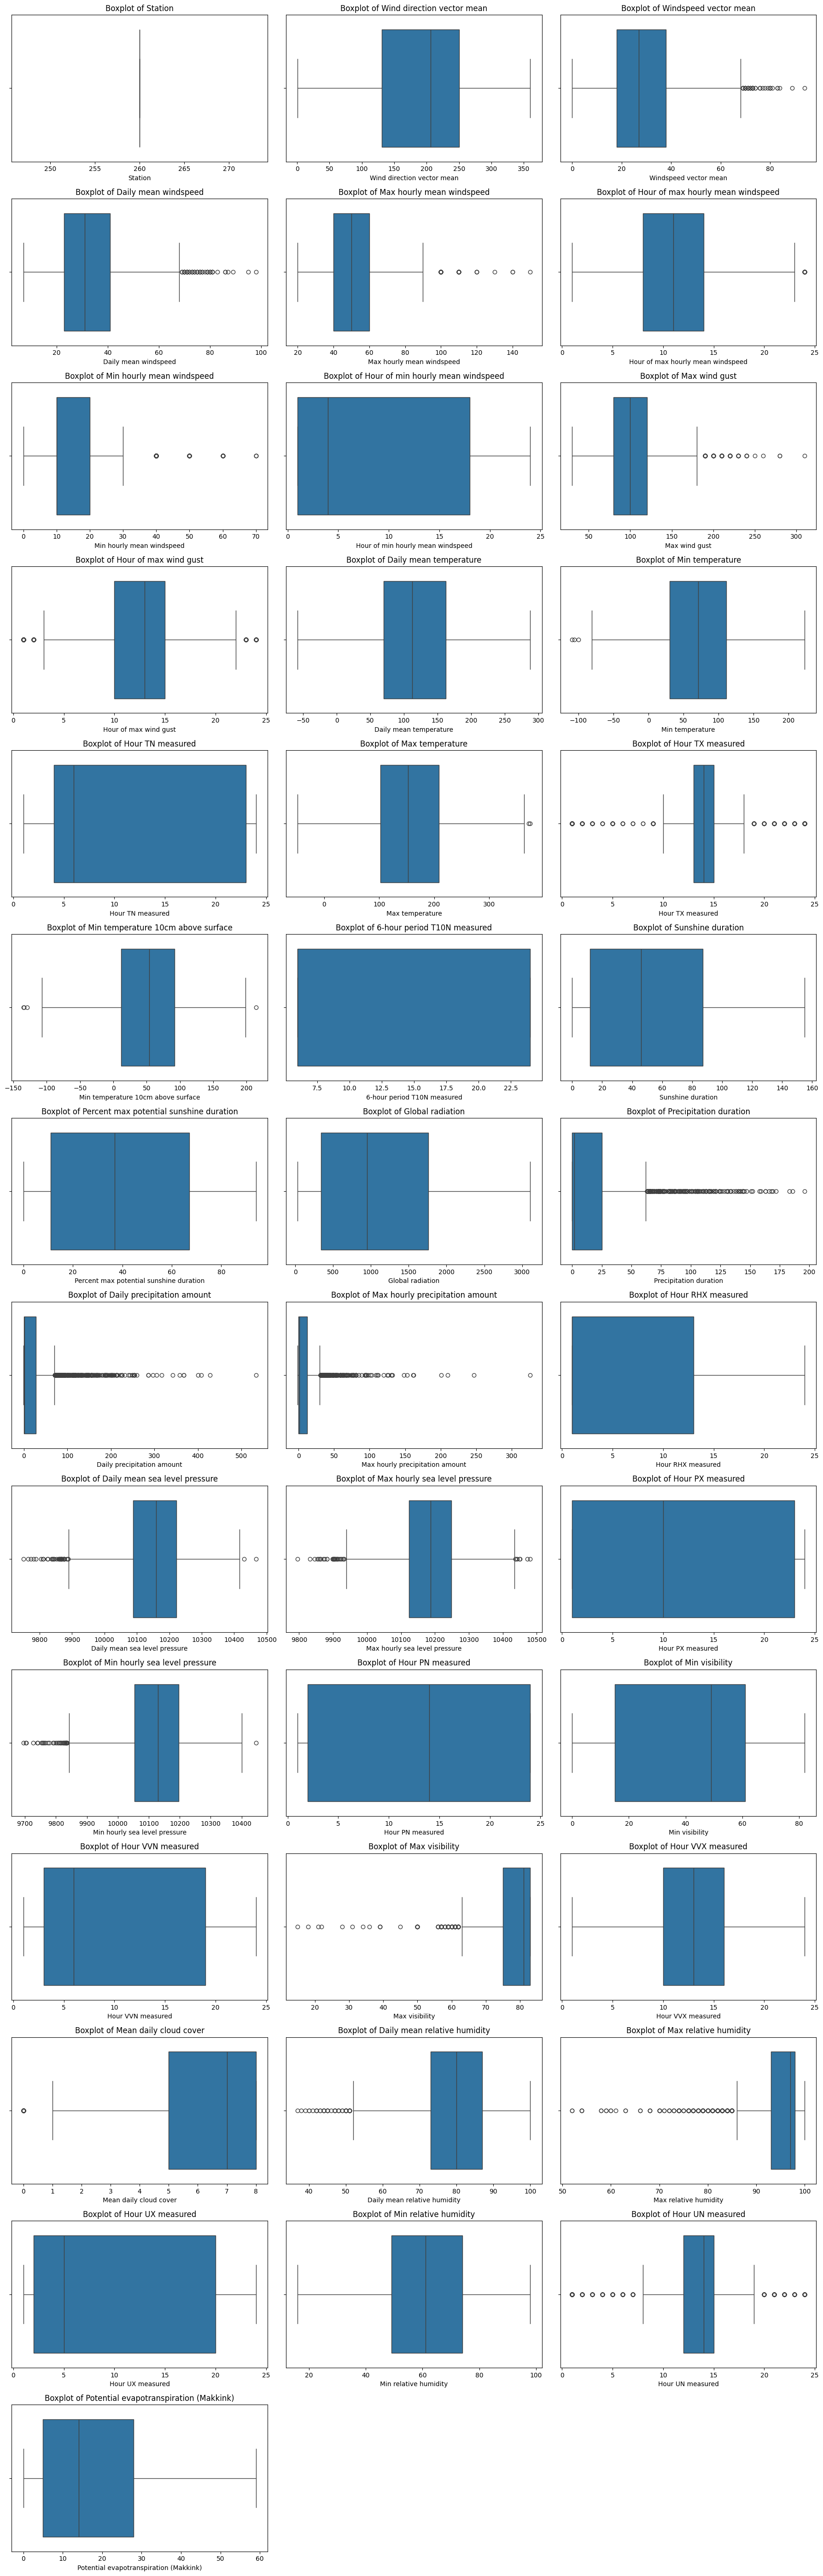

In [40]:
#boxplot: for outliers and data spread
num_cols = weather.select_dtypes(include=[np.number]).columns
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=weather[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

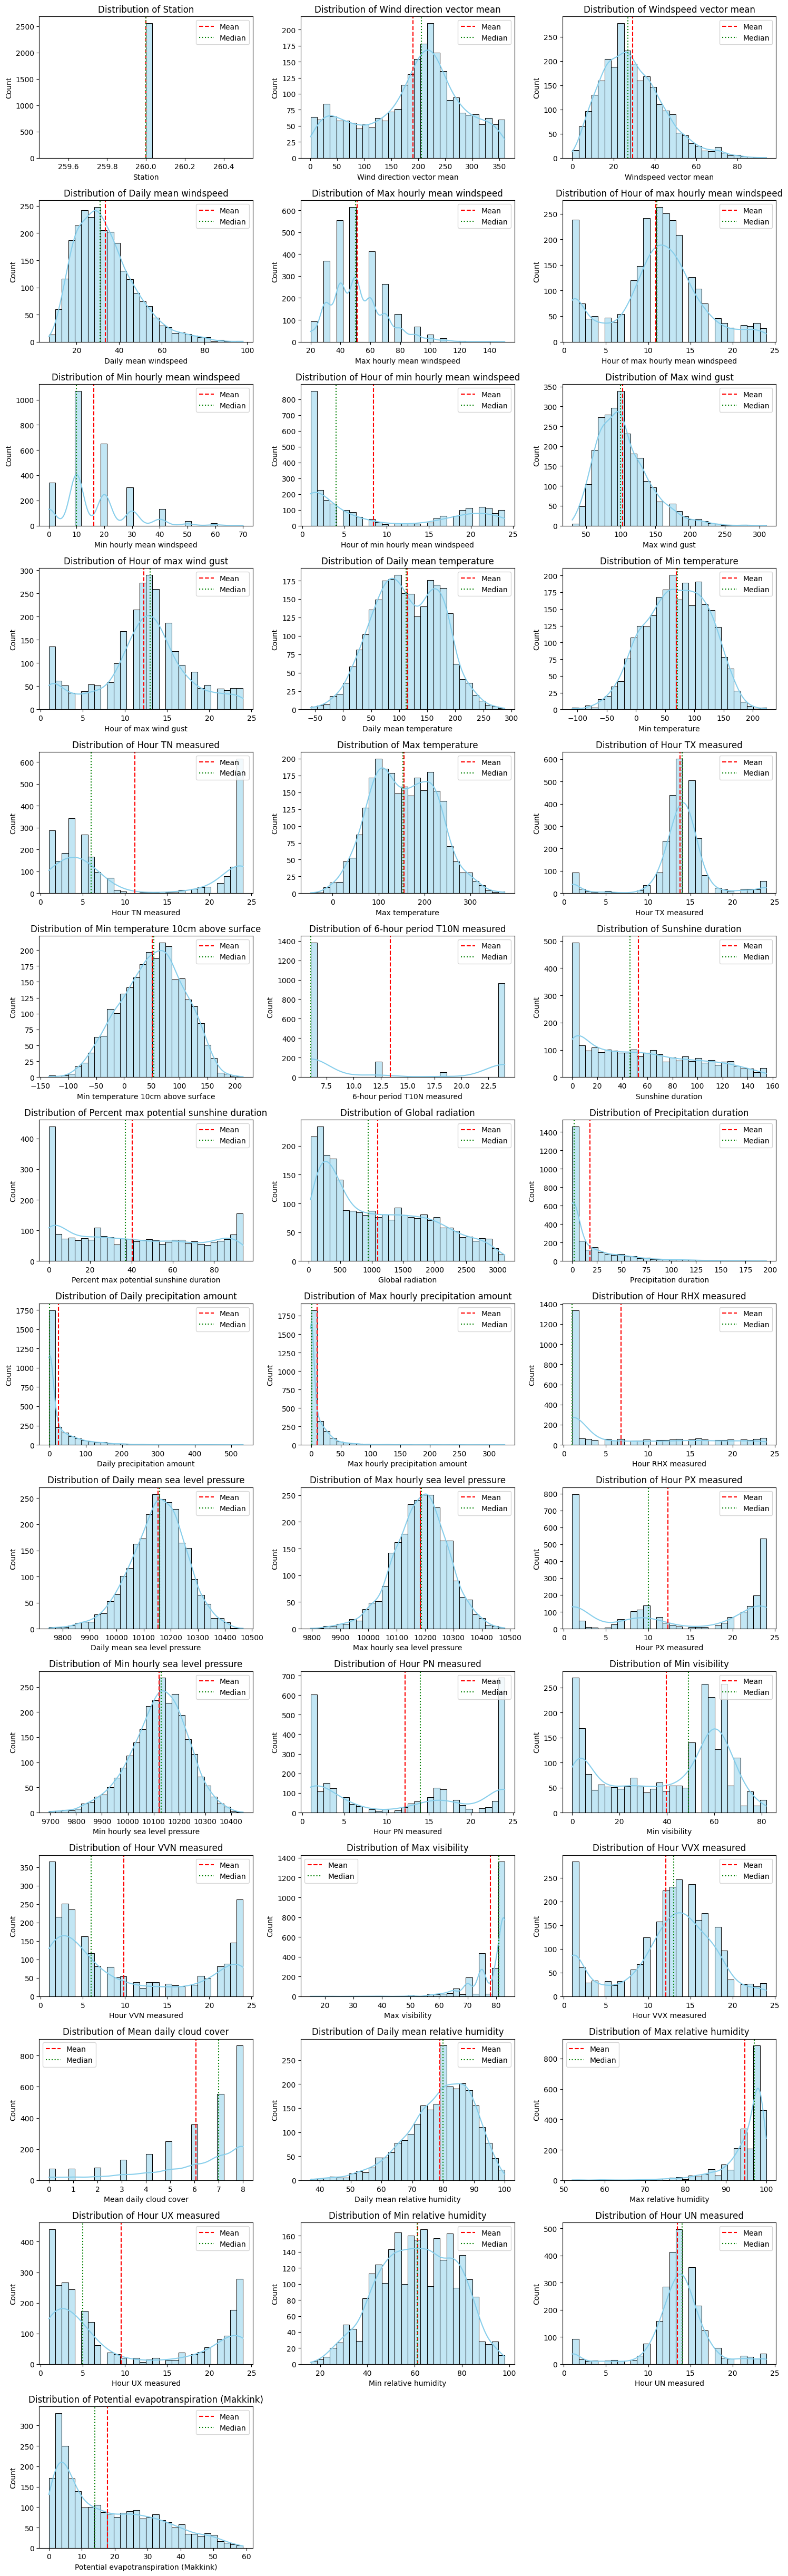

In [41]:
#histogram: for distribution and central tendency (mean, median)
n = len(num_cols)
n_cols = 3
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    data = weather[col].dropna()
    sns.histplot(data, bins=30, kde=True, ax=ax, color="skyblue")
    ax.axvline(data.mean(), color="red", linestyle="--", label="Mean")
    ax.axvline(data.median(), color="green", linestyle=":", label="Median")
    ax.set_title(f"Distribution of {col}")
    ax.set_ylabel("Count")
    ax.legend()

for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

### Preprocessing Weather: Bivariate

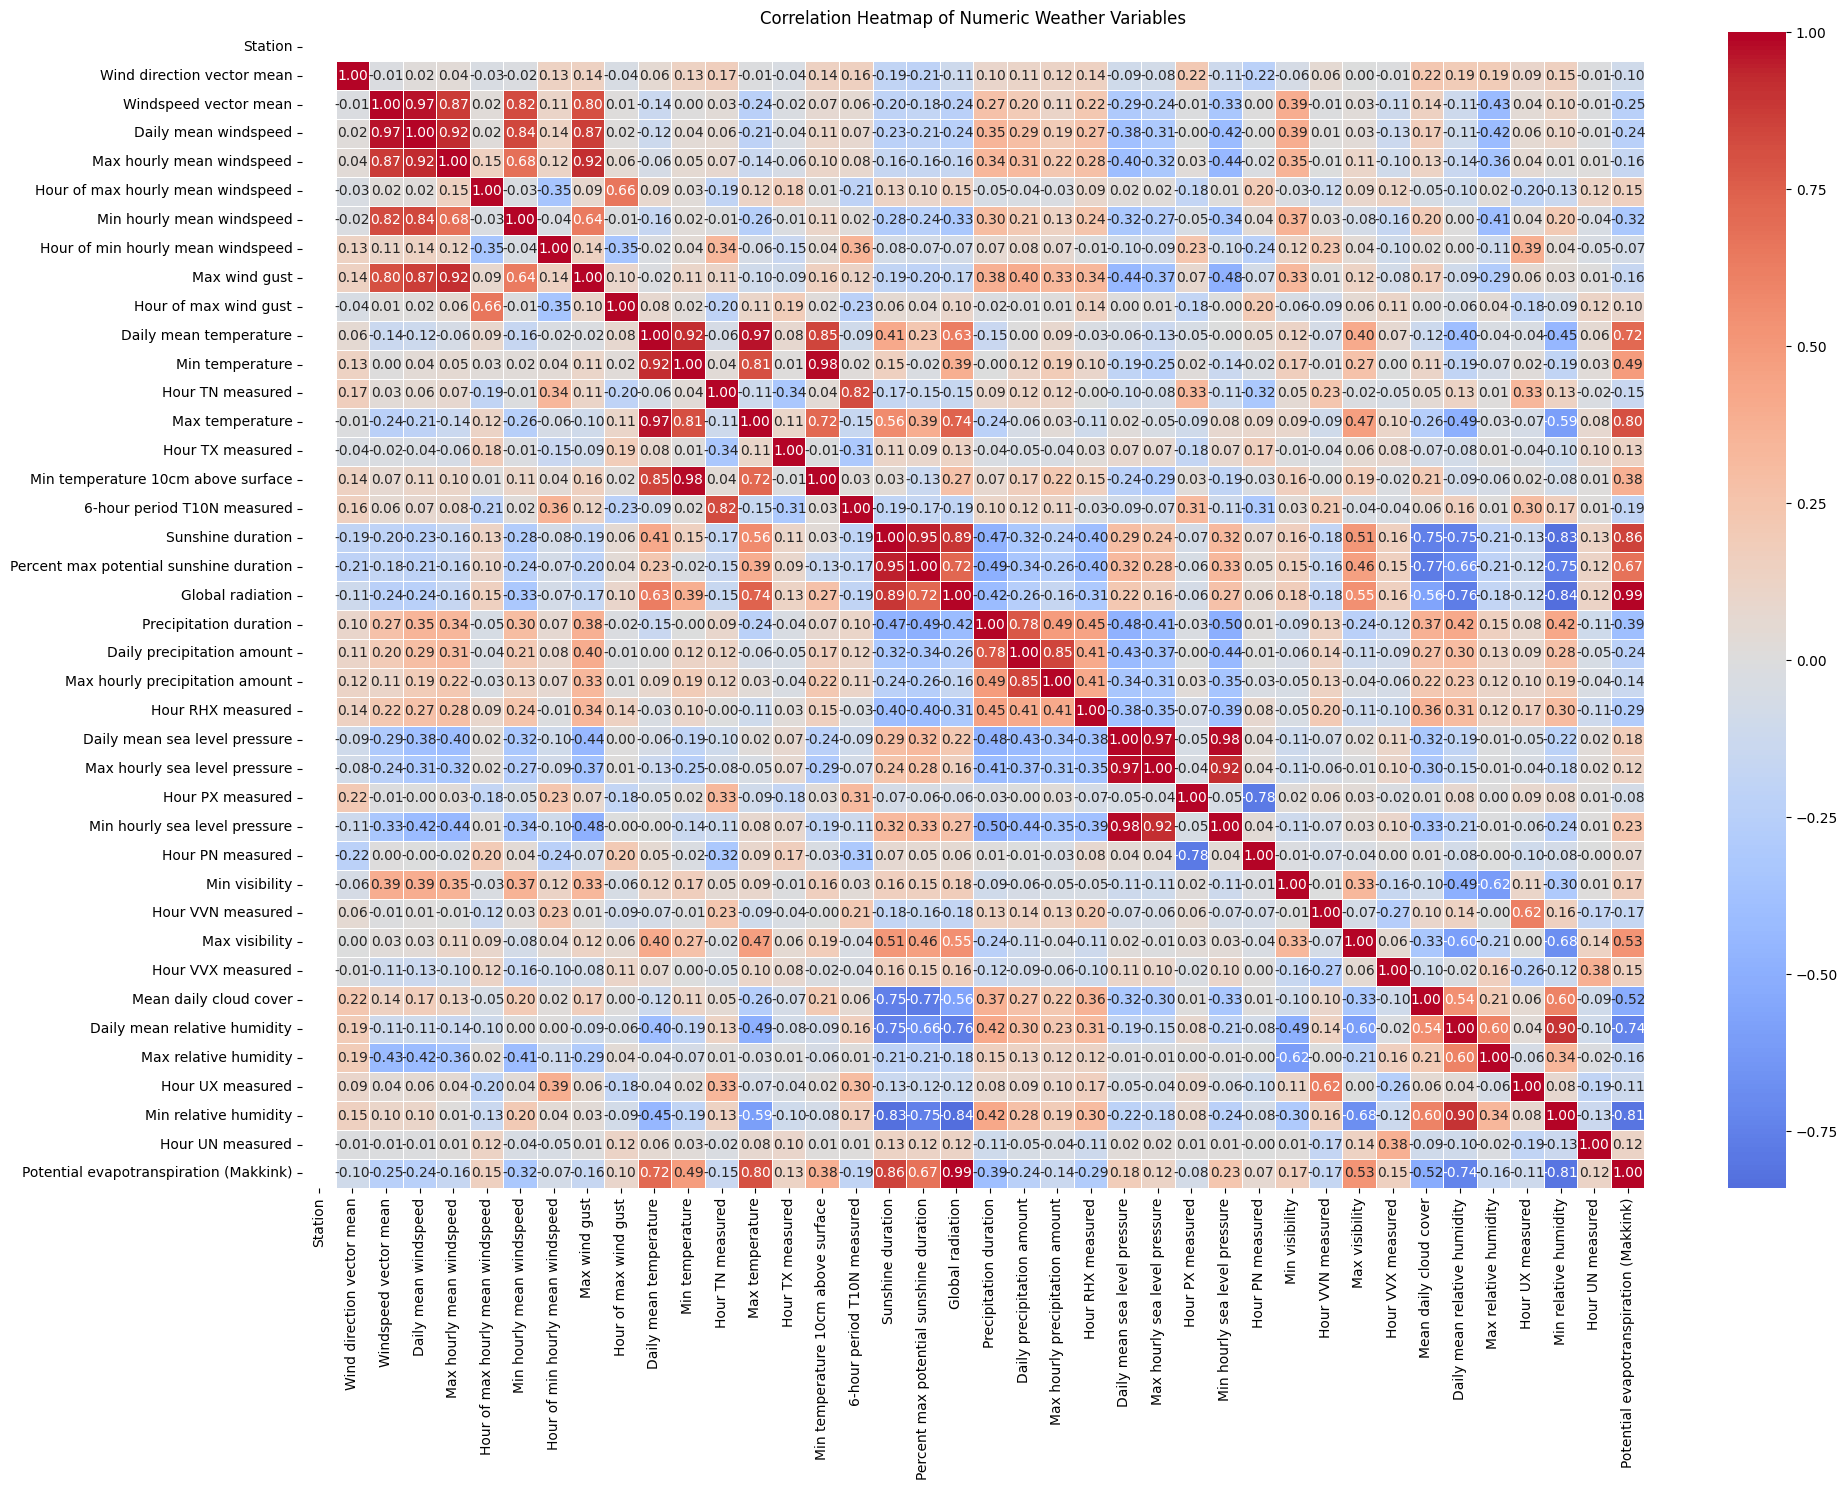

In [42]:
#heatmap: for correlation between numeric variables
corr = weather[num_cols].corr()

plt.figure(figsize=(20, 15))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.5, annot=True, fmt=".2f")
plt.title("Correlation Heatmap of Numeric Weather Variables")
plt.tight_layout()
plt.show()

In [43]:
#check the top 10 most correlated pairs of numeric variables
corr_abs = weather[num_cols].corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

top_pairs = upper.stack().sort_values(ascending=False).head(10)
print(top_pairs)

Global radiation               Potential evapotranspiration (Makkink)     0.986972
Min temperature                Min temperature 10cm above surface         0.980163
Daily mean sea level pressure  Min hourly sea level pressure              0.978490
                               Max hourly sea level pressure              0.974933
Daily mean temperature         Max temperature                            0.966511
Windspeed vector mean          Daily mean windspeed                       0.965609
Sunshine duration              Percent max potential sunshine duration    0.948298
Daily mean windspeed           Max hourly mean windspeed                  0.921756
Max hourly sea level pressure  Min hourly sea level pressure              0.919462
Daily mean temperature         Min temperature                            0.918034
dtype: float64


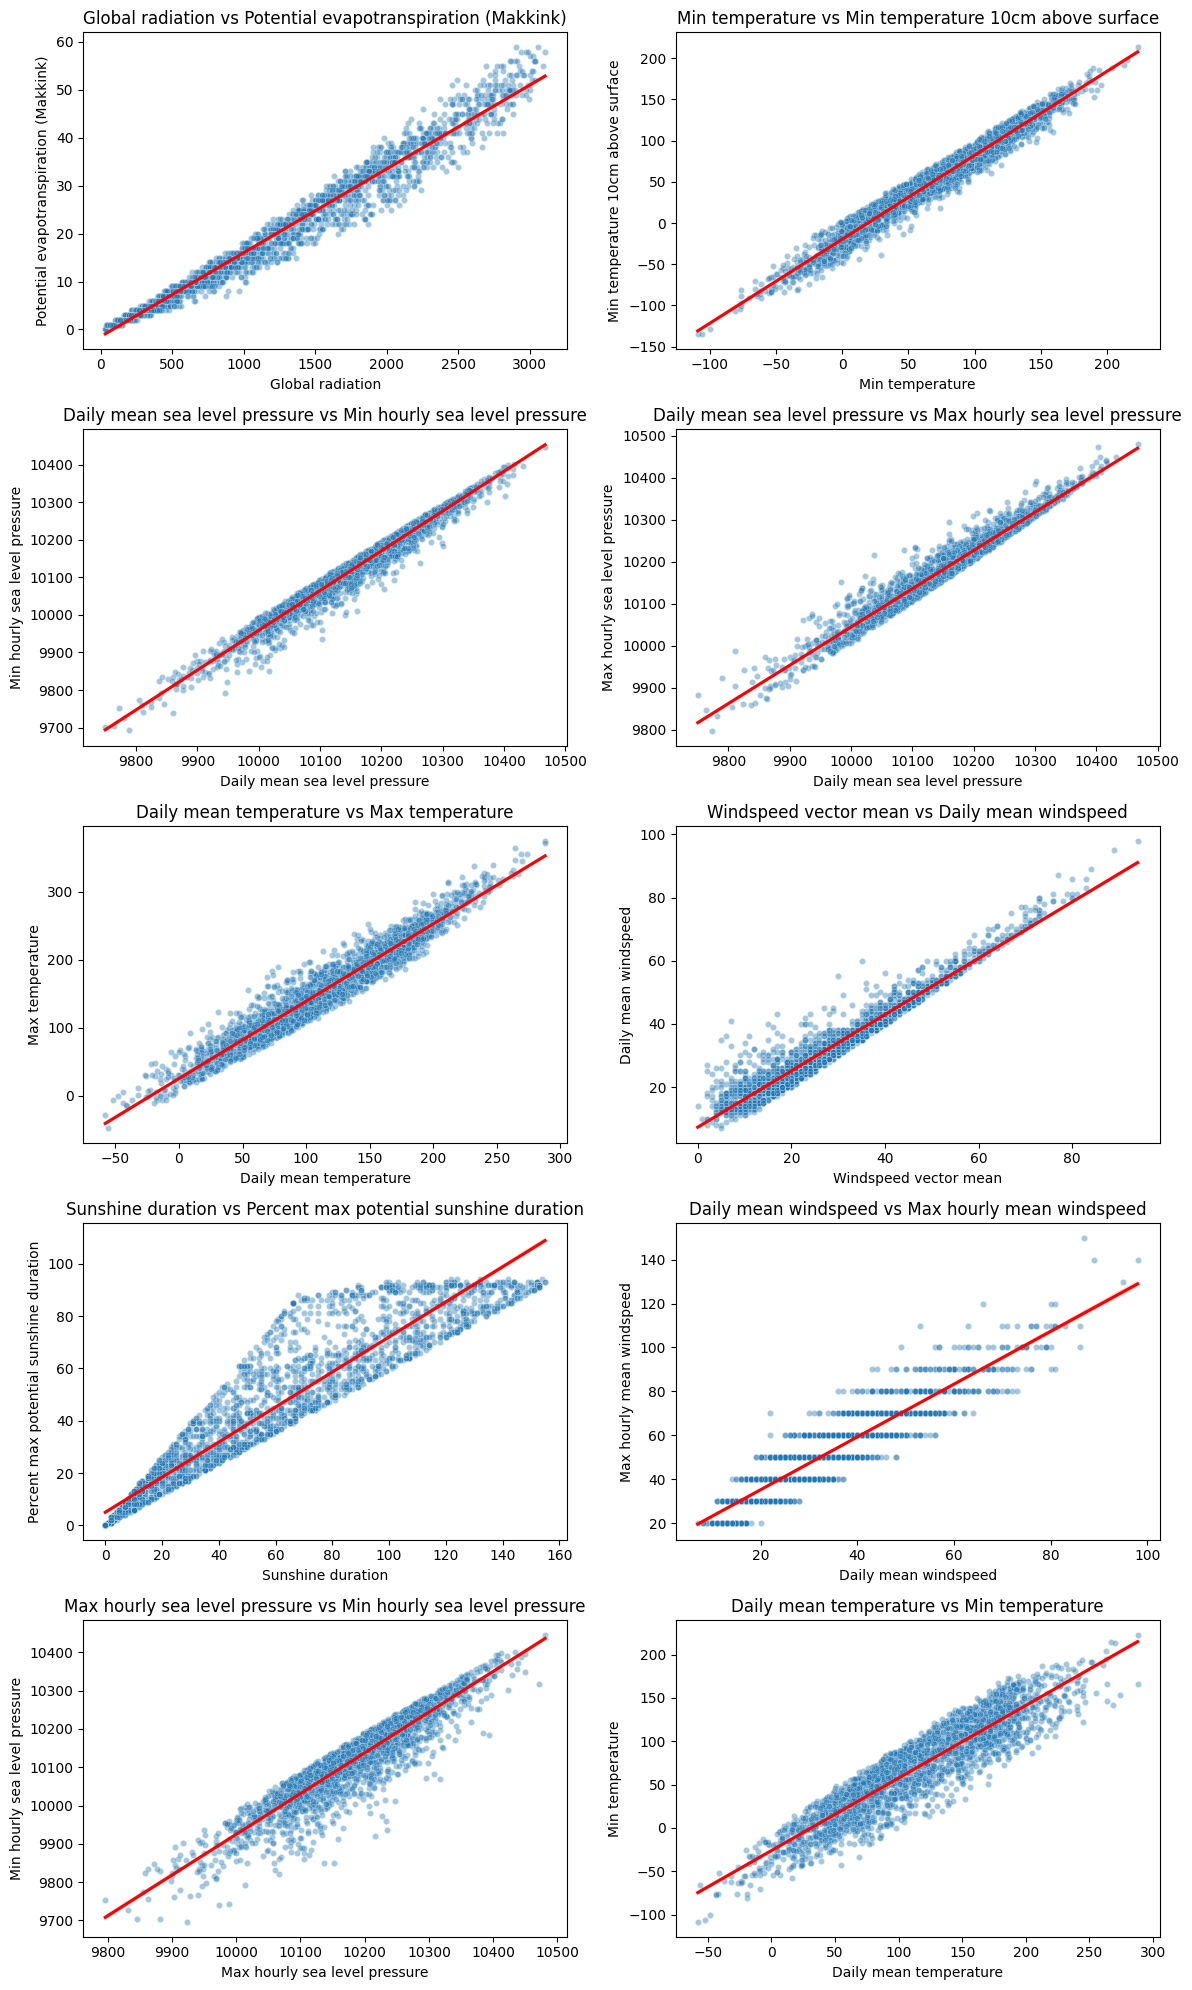

In [44]:
pairs = top_pairs.head(10).index.tolist()

n_pairs = len(pairs)
n_cols = 2
n_rows = math.ceil(n_pairs / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = np.array(axes).flatten()

for ax, (x, y) in zip(axes, pairs):
    sns.scatterplot(data=weather, x=x, y=y, alpha=0.4, s=20, ax=ax)
    sns.regplot(data=weather, x=x, y=y, scatter=False, color="red", ax=ax)
    ax.set_title(f"{x} vs {y}")

for ax in axes[n_pairs:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()